<a href="https://colab.research.google.com/github/alii07700/CS308/blob/main/PURE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Load the CSV
file_path = "Impact of AI-assisted Reading Tools on University Learners' Academic and Critical Reading Skills (Responses) - Form Responses 1.csv"
df = pd.read_csv(file_path)

# Define columns
question_col = 'What do you think might be the main point the author is trying to make about the Chinese government and farming during the late imperial period?'
ai_usage_col = 'Have you used AI or not in the summarizing part ?'

# Drop NA and clean documents
documents = df[question_col].dropna().astype(str).tolist()
cleaned_docs = [re.sub(r'[^a-zA-Z\s]', '', doc.lower()) for doc in documents]

# Vectorize
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(cleaned_docs)
feature_names = vectorizer.get_feature_names_out()

# Train LDA
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(X)

# Build weighted keyword dictionary from LDA
keyword_weights = {}
for topic in lda_model.components_:
    for i in topic.argsort()[:-11:-1]:  # Top 10 words per topic
        word = feature_names[i]
        keyword_weights[word] = keyword_weights.get(word, 0) + topic[i]

# Score each document based on keyword weights
scores = []
for doc in cleaned_docs:
    words = doc.split()
    score = sum(keyword_weights.get(word, 0) for word in words)
    scores.append(score)

# Normalize to 0–10
max_score = max(scores) if max(scores) > 0 else 1
normalized_scores = [round((s / max_score) * 10, 2) for s in scores]

# Add to dataframe
df["Thematic Relevance Score (0-10)"] = None
df.loc[df[question_col].notna(), "Thematic Relevance Score (0-10)"] = normalized_scores

# AI vs Non-AI comparison
ai_users = df[df[ai_usage_col] == "I have used ChatGPT"]
non_ai_users = df[df[ai_usage_col] == "I have not used ChatGPT"]

ai_avg = ai_users["Thematic Relevance Score (0-10)"].dropna().astype(float).mean()
non_ai_avg = non_ai_users["Thematic Relevance Score (0-10)"].dropna().astype(float).mean()

# Print comparison and keyword weights
print("🔍 Thematic Relevance Score Comparison (Weighted)")
print(f"📘 AI Users Avg Score: {round(ai_avg, 2)}")
print(f"📗 Non-AI Users Avg Score: {round(non_ai_avg, 2)}")

print("\n🎯 Weighted Keywords Used for Scoring:")
for k, v in sorted(keyword_weights.items(), key=lambda x: -x[1]):
    print(f"{k}: {round(v, 2)}")

# Save to CSV
df.to_csv("scored_responses_weighted.csv", index=False)

🔍 Thematic Relevance Score Comparison (Weighted)
📘 AI Users Avg Score: 3.91
📗 Non-AI Users Avg Score: 3.05

🎯 Weighted Keywords Used for Scoring:
government: 19.0
chinese: 19.0
economy: 17.69
agrarian: 13.67
state: 12.74
period: 8.67
late: 8.67
social: 6.35
farming: 5.33
main: 4.35
policies: 4.35
author: 4.34
agriculture: 3.4
balance: 3.37
stability: 3.36
power: 3.36
point: 3.35
imperial: 3.34
elites: 3.34
private: 3.34
welfare: 3.33


In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Load CSV
file_path = "Impact of AI-assisted Reading Tools on University Learners' Academic and Critical Reading Skills (Responses) - Form Responses 1.csv"
df = pd.read_csv(file_path)

# Define columns
question_col_2 = 'Which parts of the text might support the author’s main point? Mention one or two examples and explain how they might help support the main idea.'
ai_usage_col = 'Have you used AI or not in the summarizing part ?'

# Clean text
documents2 = df[question_col_2].dropna().astype(str).tolist()
cleaned_docs2 = [re.sub(r'[^a-zA-Z\s]', '', doc.lower()) for doc in documents2]

# Vectorize
vectorizer2 = CountVectorizer(stop_words='english')
X2 = vectorizer2.fit_transform(cleaned_docs2)
feature_names2 = vectorizer2.get_feature_names_out()

# LDA Model
lda2 = LatentDirichletAllocation(n_components=3, random_state=42)
lda2.fit(X2)

# Calculate keyword weights from top 10 keywords in each topic
keyword_weights2 = {}
for topic in lda2.components_:
    for i in topic.argsort()[:-11:-1]:
        word = feature_names2[i]
        keyword_weights2[word] = keyword_weights2.get(word, 0) + topic[i]

# Score each document
scores2 = []
for doc in cleaned_docs2:
    words = doc.split()
    score = sum(keyword_weights2.get(word, 0) for word in words)
    scores2.append(score)

# Normalize to 0–10
max_score2 = max(scores2) if max(scores2) > 0 else 1
normalized_scores2 = [round((s / max_score2) * 10, 2) for s in scores2]

# Add to dataframe
df["Support Relevance Score (0-10)"] = None
df.loc[df[question_col_2].notna(), "Support Relevance Score (0-10)"] = normalized_scores2

# AI vs Non-AI average score comparison
ai_users = df[df[ai_usage_col] == "I have used ChatGPT"]
non_ai_users = df[df[ai_usage_col] == "I have not used ChatGPT"]

ai_avg = ai_users["Support Relevance Score (0-10)"].dropna().astype(float).mean()
non_ai_avg = non_ai_users["Support Relevance Score (0-10)"].dropna().astype(float).mean()

print("\n📊 Support Relevance Score Averages:")
print(f"AI Users Average: {round(ai_avg, 2)}")
print(f"Non-AI Users Average: {round(non_ai_avg, 2)}")

# Create keyword-topic weight breakdown
n_topics = 3
topic_keyword_matrix = []

for i, word in enumerate(feature_names2):
    row = {"Keyword": word}
    total = 0
    for t in range(n_topics):
        weight = lda2.components_[t][i]
        row[f"Topic {t}"] = round(weight, 2)
        total += weight
    row["Total Weight"] = round(total, 2)
    topic_keyword_matrix.append(row)

# Create and save DataFrame
keyword_topic_df2 = pd.DataFrame(topic_keyword_matrix)
used_keywords_df2 = keyword_topic_df2[keyword_topic_df2["Keyword"].isin(keyword_weights2.keys())]
used_keywords_df2 = used_keywords_df2.sort_values("Total Weight", ascending=False).reset_index(drop=True)

# Export results
df.to_csv("support_question_scored.csv", index=False)
# Keyword breakdown'ı terminale yazdır
print("\n🎯 Weighted Keywords Used for Scoring (Support Question):")
for _, row in used_keywords_df2.iterrows():
    print(
        f"{row['Keyword']:>15} | "
        f"Total: {row['Total Weight']:>5}"
    )

print("\n✅ CSV files saved: 'support_question_scored.csv' and 'support_question_keywords.csv'")


📊 Support Relevance Score Averages:
AI Users Average: 2.68
Non-AI Users Average: 3.56

🎯 Weighted Keywords Used for Scoring (Support Question):
          state | Total:  28.0
           land | Total:  21.0
        economy | Total:  16.0
       economic | Total:  14.0
   distribution | Total:  13.0
        society | Total:  11.0
           main | Total:  10.0
      dynasties | Total:  10.0
         social | Total:  10.0
       agrarian | Total:   9.0
       policies | Total:   9.0
        efforts | Total:   9.0
        control | Total:   9.0
     government | Total:   9.0
      paragraph | Total:   9.0
       families | Total:   8.0
         states | Total:   8.0
            sui | Total:   7.0
        chinese | Total:   7.0
          order | Total:   7.0
     landowners | Total:   7.0
          taxes | Total:   6.0
         author | Total:   5.0
          elite | Total:   5.0
           kind | Total:   5.0

✅ CSV files saved: 'support_question_scored.csv' and 'support_question_keywords

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Dosyayı yükle
file_path = "Impact of AI-assisted Reading Tools on University Learners' Academic and Critical Reading Skills (Responses) - Form Responses 1.csv"
df = pd.read_csv(file_path)

# 2. Hedef sütun (3. açık uçlu soru)
question_col_3 = 'Do you think the author expresses any bias or particular perspective regarding the role of the state in shaping the agrarian economy during the late imperial period in China?'
ai_usage_col = 'Have you used AI or not in the summarizing part ?'

# 3. Yanıtları temizle
documents3 = df[question_col_3].dropna().astype(str).tolist()
cleaned_docs3 = [re.sub(r'[^a-zA-Z\s]', '', doc.lower()) for doc in documents3]

# 4. Vektörleştirme
vectorizer3 = CountVectorizer(stop_words='english')
X3 = vectorizer3.fit_transform(cleaned_docs3)
feature_names3 = vectorizer3.get_feature_names_out()

# 5. LDA ile 3 topic (her topic için 6 kelime)
lda3 = LatentDirichletAllocation(n_components=3, random_state=42)
lda3.fit(X3)

# 6. Tematik kelimeleri ve ağırlıkları
keyword_weights3 = {}
for topic in lda3.components_:
    for i in topic.argsort()[:-7:-1]:  # Her topic için 6 kelime al
        word = feature_names3[i]
        keyword_weights3[word] = keyword_weights3.get(word, 0) + topic[i]

# 7. Yanıt başına skor hesapla
scores3 = []
for doc in cleaned_docs3:
    words = doc.split()
    score = sum(keyword_weights3.get(word, 0) for word in words)
    scores3.append(score)

# 8. Normalize et (0-10)
max_score3 = max(scores3) if max(scores3) > 0 else 1
normalized_scores3 = [round((s / max_score3) * 10, 2) for s in scores3]

# 9. DataFrame'e ekle
df["Bias Relevance Score (0-10)"] = None
df.loc[df[question_col_3].notna(), "Bias Relevance Score (0-10)"] = normalized_scores3

# 10. AI vs Non-AI karşılaştırması
ai_users = df[df[ai_usage_col] == "I have used ChatGPT"]
non_ai_users = df[df[ai_usage_col] == "I have not used ChatGPT"]

ai_avg_bias = ai_users["Bias Relevance Score (0-10)"].dropna().astype(float).mean()
non_ai_avg_bias = non_ai_users["Bias Relevance Score (0-10)"].dropna().astype(float).mean()

print("\n📊 Bias Relevance Score Averages:")
print(f"AI Users Average: {round(ai_avg_bias, 2)}")
print(f"Non-AI Users Average: {round(non_ai_avg_bias, 2)}")

# 11. Tematik kelimeleri yazdır (CSV yok, sadece terminal)
print("\n🎯 Weighted Keywords Used for Scoring (Bias Question):")
for word, weight in sorted(keyword_weights3.items(), key=lambda x: -x[1]):
    print(f"{word:>15} : {round(weight, 2)}")


📊 Bias Relevance Score Averages:
AI Users Average: 3.36
Non-AI Users Average: 2.78

🎯 Weighted Keywords Used for Scoring (Bias Question):
         author : 23.0
           bias : 13.61
    perspective : 10.68
            yes : 10.32
          state : 9.75
           does : 4.34
          think : 4.33
        economy : 4.33
           role : 3.41
          force : 2.37
      stability : 2.36
      strategic : 2.33
        revenue : 2.33


In [ ]:
pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

BERT KODLARI;SEMANTİC ANALİZ

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. BERT modelini yükle
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Temel tematik vektör tanımla (örnek: economy + agriculture + state gibi)
core_keywords = ["agrarian", "tax", "commerce", "revenue", "state"]
core_embedding = model.encode(" ".join(core_keywords)).reshape(1, -1)

# 3. Her kelime için embedding oluştur ve benzerliğe göre ağırlık çarpanı uygula
adjusted_keyword_weights = {}
for word, original_weight in keyword_weights.items():
    try:
        word_embedding = model.encode(word).reshape(1, -1)
        similarity = cosine_similarity(word_embedding, core_embedding)[0][0]
        multiplier = similarity  # yüksek benzerlik = yüksek puan
        adjusted_weight = original_weight * multiplier
        adjusted_keyword_weights[word] = adjusted_weight
    except Exception as e:
        adjusted_keyword_weights[word] = original_weight  # fallback

# 4. Yeni skorları hesapla
bert_scores = []
for doc in cleaned_docs:
    words = doc.split()
    score = sum(adjusted_keyword_weights.get(word, 0) for word in words)
    bert_scores.append(score)

# 5. Normalize et
max_bert_score = max(bert_scores) if max(bert_scores) > 0 else 1
normalized_bert_scores = [round((s / max_bert_score) * 10, 2) for s in bert_scores]

# 6. DataFrame'e ekle
df["Thematic Score with BERT (0-10)"] = None
df.loc[df[question_col].notna(), "Thematic Score with BERT (0-10)"] = normalized_bert_scores

# 7. Ortalamaları karşılaştır
ai_avg_bert = df[df[ai_usage_col] == "I have used ChatGPT"]["Thematic Score with BERT (0-10)"].dropna().astype(float).mean()
non_ai_avg_bert = df[df[ai_usage_col] == "I have not used ChatGPT"]["Thematic Score with BERT (0-10)"].dropna().astype(float).mean()

print("\n🧠 Thematic Score with BERT Semantic Adjustment")
print(f"📘 AI Users Avg Score: {round(ai_avg_bert, 2)}")
print(f"📗 Non-AI Users Avg Score: {round(non_ai_avg_bert, 2)}")


🧠 Thematic Score with BERT Semantic Adjustment
📘 AI Users Avg Score: 3.58
📗 Non-AI Users Avg Score: 2.75


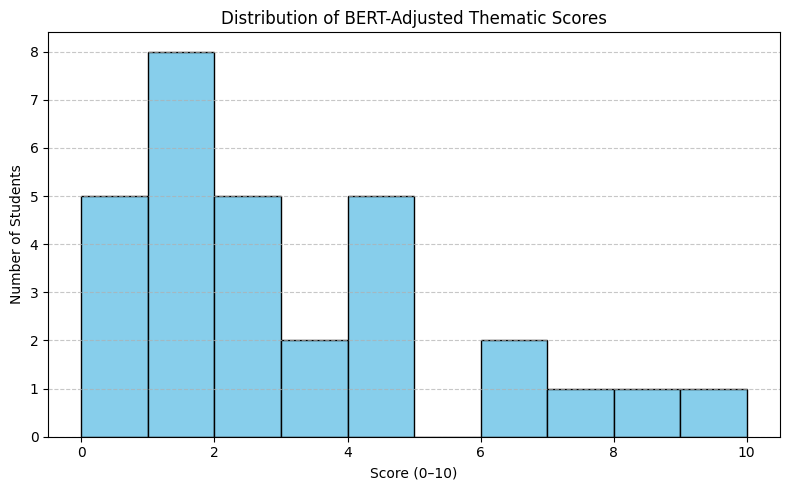

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Thematic Score with BERT (0-10)"].dropna(), bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of BERT-Adjusted Thematic Scores")
plt.xlabel("Score (0–10)")
plt.ylabel("Number of Students")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<ipython-input-32-b4be09c887e5>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Thematic Score with BERT (0-10)"].notna()],


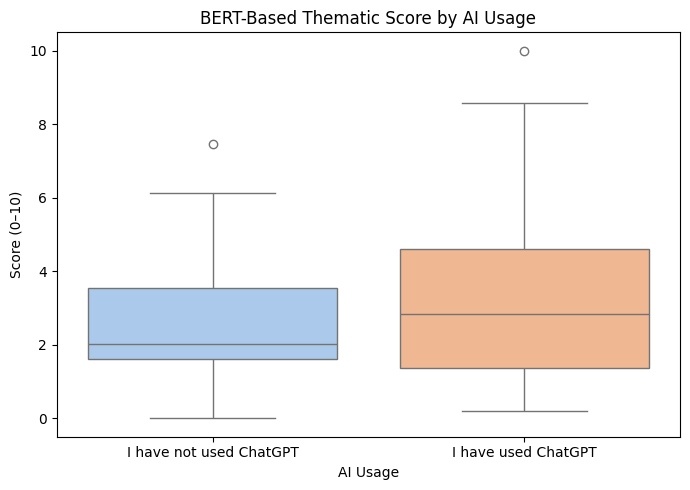

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df[df["Thematic Score with BERT (0-10)"].notna()],
            x=ai_usage_col, y="Thematic Score with BERT (0-10)", palette="pastel")
plt.title("BERT-Based Thematic Score by AI Usage")
plt.xlabel("AI Usage")
plt.ylabel("Score (0–10)")
plt.tight_layout()
plt.show()

LDA da olan ama cevaba semantic etkisi az olan kelimelerin puan olarak düşürülmesi

In [ ]:
# 2. soru için kelime bazlı ağırlık düşüşü hesapla ve yazdır
bert_debug = pd.DataFrame([
    {"Keyword": word,
     "LDA Weight": keyword_weights2[word],
     "BERT Weight": adjusted_keyword_weights2[word]}
    for word in keyword_weights2
])

bert_debug["Drop (%)"] = round((1 - bert_debug["BERT Weight"] / bert_debug["LDA Weight"]) * 100, 1)
bert_debug = bert_debug.sort_values("Drop (%)", ascending=False)

print("\n🔍 Kelime Bazında Ağırlık Düşüşü (LDA vs BERT) – Support Question:")
print(bert_debug.head(10).to_string(index=False))


🔍 Kelime Bazında Ağırlık Düşüşü (LDA vs BERT) – Support Question:
     Keyword  LDA Weight  BERT Weight  Drop (%)
   paragraph    6.332412     0.062713      99.0
      social    5.345858     0.098505      98.2
       order    4.335982     0.084223      98.1
     chinese    5.357326     0.109942      97.9
       elite    4.333184     0.092070      97.9
      author    4.333033     0.098714      97.7
        kind    4.333233     0.102753      97.6
     efforts    5.345715     0.173520      96.8
distribution   10.674454     0.426979      96.0
        main    5.350514     0.217609      95.9


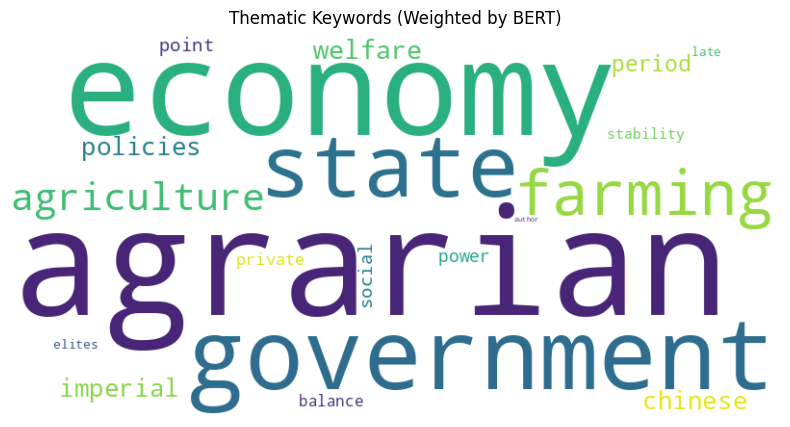

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(adjusted_keyword_weights)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Thematic Keywords (Weighted by BERT)")
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. BERT modelini yükle
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Tematik merkez vektörü oluştur
core_keywords = ["land", "salt", "voucher", "mining", "market","regulation"]
core_embedding = model.encode(" ".join(core_keywords)).reshape(1, -1)

# 3. Kelime bazlı ağırlıkları semantic benzerlik ile yeniden ölçekle
adjusted_keyword_weights2 = {}
for word, original_weight in keyword_weights2.items():
    try:
        word_embedding = model.encode(word).reshape(1, -1)
        similarity = cosine_similarity(word_embedding, core_embedding)[0][0]
        adjusted_weight = original_weight * similarity
        adjusted_keyword_weights2[word] = adjusted_weight
    except Exception as e:
        adjusted_keyword_weights2[word] = original_weight  # fallback

# 4. Öğrenci cevaplarına göre yeniden skorla
bert_scores2 = []
for doc in cleaned_docs2:
    words = doc.split()
    score = sum(adjusted_keyword_weights2.get(word, 0) for word in words)
    bert_scores2.append(score)

# 5. Normalize et
max_bert_score2 = max(bert_scores2) if max(bert_scores2) > 0 else 1
normalized_bert_scores2 = [round((s / max_bert_score2) * 10, 2) for s in bert_scores2]

# 6. DataFrame'e ekle
df["Support Relevance Score (BERT-adjusted)"] = None
df.loc[df[question_col_2].notna(), "Support Relevance Score (BERT-adjusted)"] = normalized_bert_scores2

# 7. AI vs Non-AI karşılaştırması
ai_bert_avg = df[df[ai_usage_col] == "I have used ChatGPT"]["Support Relevance Score (BERT-adjusted)"].dropna().astype(float).mean()
non_ai_bert_avg = df[df[ai_usage_col] == "I have not used ChatGPT"]["Support Relevance Score (BERT-adjusted)"].dropna().astype(float).mean()

# 8. Yazdır
print("\n🧠 BERT-Adjusted Thematic Score Averages:")
print(f"📘 AI Users Average: {round(ai_bert_avg, 2)}")
print(f"📗 Non-AI Users Average: {round(non_ai_bert_avg, 2)}")

# 9. Kelime düzeyinde ağırlık değişimini yazdır
print("\n🔍 Keyword Weight Adjustment (LDA vs BERT):")
for word in sorted(adjusted_keyword_weights2, key=adjusted_keyword_weights2.get, reverse=True):
    lda_weight = keyword_weights2[word]
    bert_weight = adjusted_keyword_weights2[word]
    drop_pct = round((1 - bert_weight / lda_weight) * 100, 1) if lda_weight else 0
    print(f"{word:>15} | LDA: {round(lda_weight,2):>5} | BERT: {round(bert_weight,2):>5} | Drop: {drop_pct:>4}%")


🧠 BERT-Adjusted Thematic Score Averages:
📘 AI Users Average: 3.08
📗 Non-AI Users Average: 3.71

🔍 Keyword Weight Adjustment (LDA vs BERT):
           land | LDA: 16.67 | BERT:  5.19 | Drop: 68.9%
          state | LDA:  28.0 | BERT:  3.84 | Drop: 86.3%
       economic | LDA: 11.67 | BERT:  2.41 | Drop: 79.3%
     landowners | LDA:  5.34 | BERT:   1.8 | Drop: 66.3%
        economy | LDA:  8.35 | BERT:  1.73 | Drop: 79.2%
       agrarian | LDA:  4.35 | BERT:  1.46 | Drop: 66.3%
       policies | LDA:  5.35 | BERT:  1.33 | Drop: 75.1%
     government | LDA:  5.36 | BERT:  1.11 | Drop: 79.4%
          taxes | LDA:  5.33 | BERT:  0.94 | Drop: 82.4%
         states | LDA:  4.35 | BERT:  0.66 | Drop: 84.9%
       families | LDA:  6.36 | BERT:  0.65 | Drop: 89.8%
        control | LDA:  5.35 | BERT:  0.51 | Drop: 90.4%
   distribution | LDA: 10.67 | BERT:  0.43 | Drop: 96.0%
      dynasties | LDA:  5.33 | BERT:  0.39 | Drop: 92.7%
        society | LDA:  4.34 | BERT:  0.34 | Drop: 92.2%
     

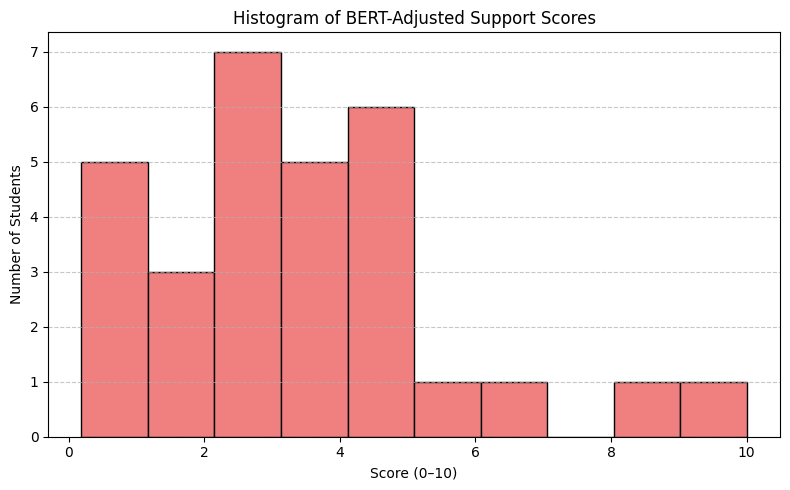

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Support Relevance Score (BERT-adjusted)"].dropna(), bins=10, color="lightcoral", edgecolor="black")
plt.title("Histogram of BERT-Adjusted Support Scores")
plt.xlabel("Score (0–10)")
plt.ylabel("Number of Students")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<ipython-input-39-17917acea0cd>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Support Relevance Score (BERT-adjusted)"].notna()],


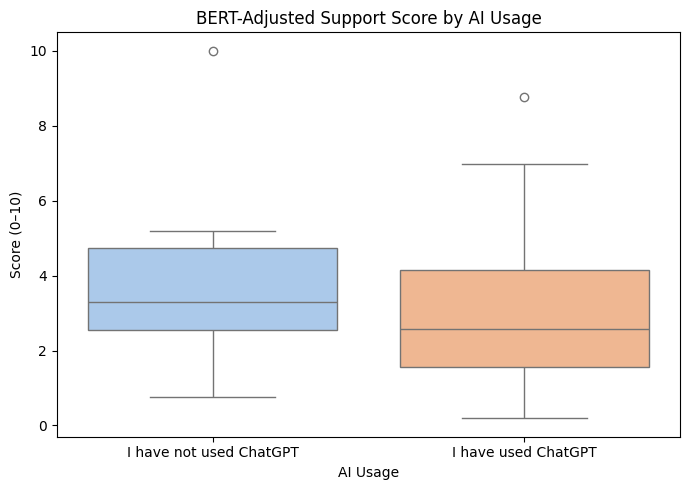

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df[df["Support Relevance Score (BERT-adjusted)"].notna()],
            x='Have you used AI or not in the summarizing part ?',
            y="Support Relevance Score (BERT-adjusted)", palette="pastel")
plt.title("BERT-Adjusted Support Score by AI Usage")
plt.xlabel("AI Usage")
plt.ylabel("Score (0–10)")
plt.tight_layout()
plt.show()

<ipython-input-40-97e254a87111>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_drops, x="Drop %", y="Keyword", palette="Reds_r")


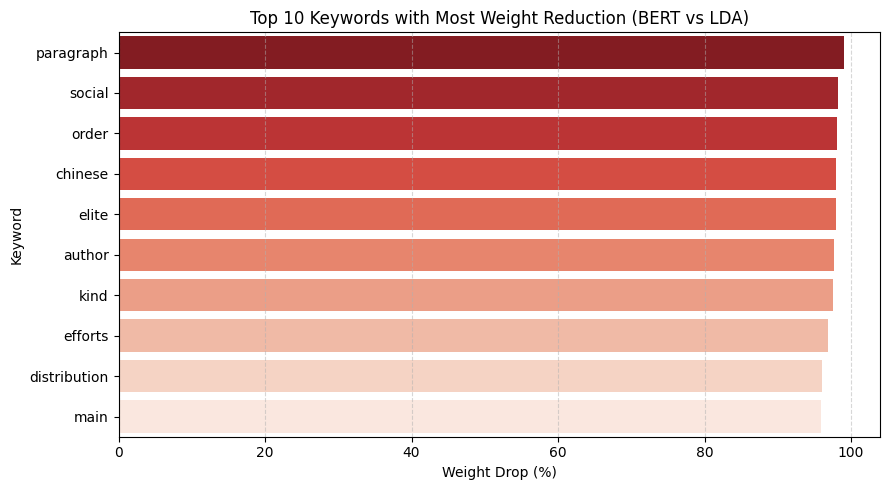

In [ ]:
import pandas as pd

bert_comparison = pd.DataFrame([
    {"Keyword": word,
     "LDA Weight": keyword_weights2[word],
     "BERT Weight": adjusted_keyword_weights2[word],
     "Drop %": round((1 - adjusted_keyword_weights2[word] / keyword_weights2[word]) * 100, 1)
     if keyword_weights2[word] else 0}
    for word in adjusted_keyword_weights2
])

top_drops = bert_comparison.sort_values("Drop %", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=top_drops, x="Drop %", y="Keyword", palette="Reds_r")
plt.title("Top 10 Keywords with Most Weight Reduction (BERT vs LDA)")
plt.xlabel("Weight Drop (%)")
plt.ylabel("Keyword")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

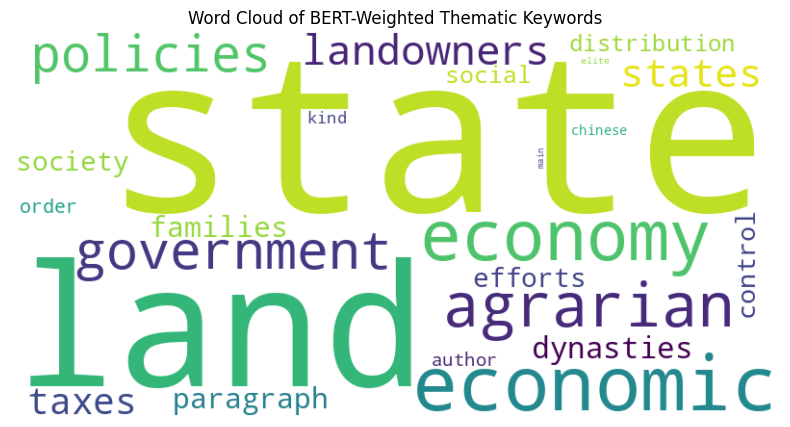

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(adjusted_keyword_weights2)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of BERT-Weighted Thematic Keywords")
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. BERT modelini yükle
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Tematik merkez vektörü oluştur (bias sorusu için anlamlı kelimeler)
core_keywords_3 = ["bias", "perspective", "state", "intervention", "role", "control"]
core_embedding_3 = model.encode(" ".join(core_keywords_3)).reshape(1, -1)

# 3. Kelime bazlı ağırlıkları semantic benzerlik ile yeniden ölçekle
adjusted_keyword_weights3 = {}
for word, original_weight in keyword_weights3.items():  # keyword_weights3 → 3. soru LDA'den gelmiş sözlük
    try:
        word_embedding = model.encode(word).reshape(1, -1)
        similarity = cosine_similarity(word_embedding, core_embedding_3)[0][0]
        adjusted_weight = original_weight * similarity
        adjusted_keyword_weights3[word] = adjusted_weight
    except Exception as e:
        adjusted_keyword_weights3[word] = original_weight  # fallback

# 4. Öğrenci cevaplarına göre yeniden skorla
bert_scores3 = []
for doc in cleaned_docs3:  # cleaned_docs3 → 3. sorunun temizlenmiş yanıt listesi
    words = doc.split()
    score = sum(adjusted_keyword_weights3.get(word, 0) for word in words)
    bert_scores3.append(score)

# 5. Normalize et
max_bert_score3 = max(bert_scores3) if max(bert_scores3) > 0 else 1
normalized_bert_scores3 = [round((s / max_bert_score3) * 10, 2) for s in bert_scores3]

# 6. DataFrame'e ekle
df["Bias Relevance Score (BERT-adjusted)"] = None
df.loc[df[question_col_3].notna(), "Bias Relevance Score (BERT-adjusted)"] = normalized_bert_scores3

# 7. AI vs Non-AI karşılaştırması
ai_bert_avg3 = df[df[ai_usage_col] == "I have used ChatGPT"]["Bias Relevance Score (BERT-adjusted)"].dropna().astype(float).mean()
non_ai_bert_avg3 = df[df[ai_usage_col] == "I have not used ChatGPT"]["Bias Relevance Score (BERT-adjusted)"].dropna().astype(float).mean()

# 8. Yazdır
print("\n🧠 BERT-Adjusted Thematic Score Averages (Bias Question):")
print(f"📘 AI Users Average: {round(ai_bert_avg3, 2)}")
print(f"📗 Non-AI Users Average: {round(non_ai_bert_avg3, 2)}")

# 9. Kelime düzeyinde ağırlık değişimini yazdır
print("\n🔍 Keyword Weight Adjustment (LDA vs BERT) – Bias Question:")
print(f"{'Keyword':>15} | {'LDA':>7} | {'BERT':>7} | {'Drop (%)':>9}")
print("-" * 45)

for word in sorted(adjusted_keyword_weights3, key=adjusted_keyword_weights3.get, reverse=True):
    lda_weight = keyword_weights3[word]
    bert_weight = adjusted_keyword_weights3[word]
    drop_pct = round((1 - bert_weight / lda_weight) * 100, 1) if lda_weight else 0
    print(f"{word:>15} | {lda_weight:7.2f} | {bert_weight:7.2f} | {drop_pct:9.1f}")


🧠 BERT-Adjusted Thematic Score Averages (Bias Question):
📘 AI Users Average: 3.51
📗 Non-AI Users Average: 2.75

🔍 Keyword Weight Adjustment (LDA vs BERT) – Bias Question:
        Keyword |     LDA |    BERT |  Drop (%)
---------------------------------------------
           bias |   13.61 |    6.10 |      55.2
         author |   23.00 |    2.64 |      88.5
          state |    9.75 |    2.43 |      75.0
    perspective |   10.68 |    2.06 |      80.7
           role |    3.41 |    1.38 |      59.6
      strategic |    2.33 |    0.60 |      74.1
            yes |   10.32 |    0.53 |      94.9
        economy |    4.33 |    0.41 |      90.6
      stability |    2.36 |    0.37 |      84.2
           does |    4.34 |    0.36 |      91.6
          force |    2.37 |    0.23 |      90.4
          think |    4.33 |    0.20 |      95.5
        revenue |    2.33 |    0.18 |      92.4


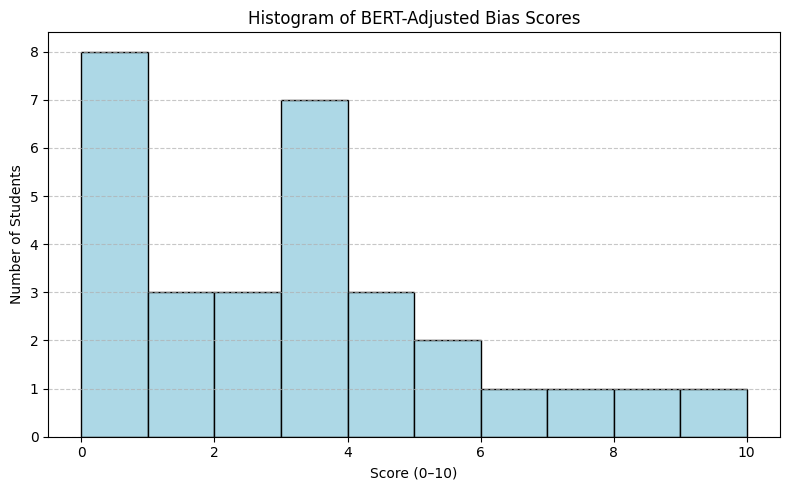

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Bias Relevance Score (BERT-adjusted)"].dropna(), bins=10, color="lightblue", edgecolor="black")
plt.title("Histogram of BERT-Adjusted Bias Scores")
plt.xlabel("Score (0–10)")
plt.ylabel("Number of Students")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<ipython-input-45-7758b379b3b3>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df["Bias Relevance Score (BERT-adjusted)"].notna()],


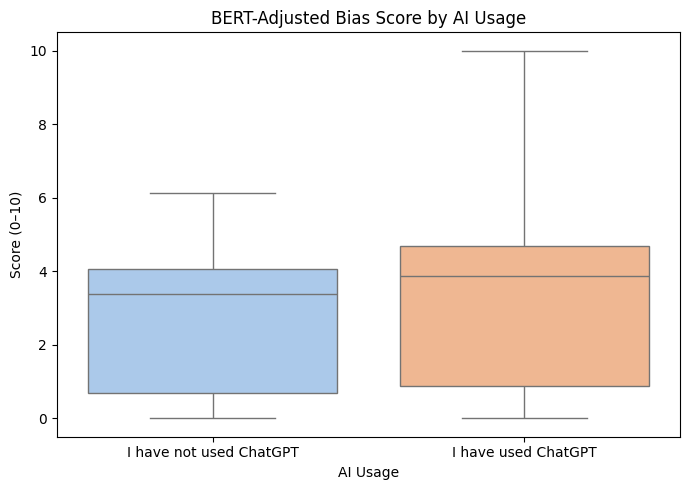

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df[df["Bias Relevance Score (BERT-adjusted)"].notna()],
            x='Have you used AI or not in the summarizing part ?',
            y="Bias Relevance Score (BERT-adjusted)", palette="pastel")
plt.title("BERT-Adjusted Bias Score by AI Usage")
plt.xlabel("AI Usage")
plt.ylabel("Score (0–10)")
plt.tight_layout()
plt.show()

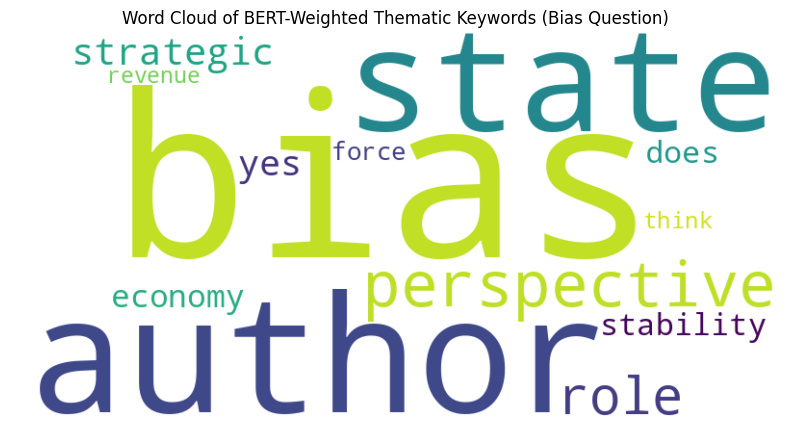

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white') \
    .generate_from_frequencies(adjusted_keyword_weights3)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of BERT-Weighted Thematic Keywords (Bias Question)")
plt.show()

In [ ]:
import pandas as pd

# BERT ve LDA ağırlık karşılaştırması tablosunu oluştur
bert_debug = pd.DataFrame([
    {"Keyword": word,
     "LDA Weight": keyword_weights3[word],
     "BERT Weight": adjusted_keyword_weights3[word]}
    for word in keyword_weights3
])

# Düşüş yüzdesini hesapla
bert_debug["Drop (%)"] = round((1 - bert_debug["BERT Weight"] / bert_debug["LDA Weight"]) * 100, 1)

# En çok düşen ilk 10 kelimeyi sırala
bert_debug = bert_debug.sort_values("Drop (%)", ascending=False).head(10)

# Yazdır
print("\n🔍 Keyword Weight Reduction – Top 10 (Bias Question)")
print(f"{'Keyword':>15} | {'LDA':>7} | {'BERT':>7} | {'Drop (%)':>9}")
print("-" * 45)

for _, row in bert_debug.iterrows():
    print(f"{row['Keyword']:>15} | {row['LDA Weight']:7.2f} | {row['BERT Weight']:7.2f} | {row['Drop (%)']:9.1f}")


🔍 Keyword Weight Reduction – Top 10 (Bias Question)
        Keyword |     LDA |    BERT |  Drop (%)
---------------------------------------------
          think |    4.33 |    0.20 |      95.5
            yes |   10.32 |    0.53 |      94.9
        revenue |    2.33 |    0.18 |      92.4
           does |    4.34 |    0.36 |      91.6
        economy |    4.33 |    0.41 |      90.6
          force |    2.37 |    0.23 |      90.4
         author |   23.00 |    2.64 |      88.5
      stability |    2.36 |    0.37 |      84.2
    perspective |   10.68 |    2.06 |      80.7
          state |    9.75 |    2.43 |      75.0
